In [82]:
import os 
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
import numpy as np
import pandas as pd
import random
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from torchsummary import summary
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch import optim
import matplotlib.pyplot as plt

In [83]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import datetime
import copy
import math
import time

In [84]:
available_gpu = [torch.cuda.device(i) for i in range(torch.cuda.device_count())]
available_gpu

[<torch.cuda.device at 0x7bbb415e17c0>, <torch.cuda.device at 0x7bbb415e1670>]

In [85]:
torch.cuda.is_available()

True

In [86]:
import os 
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'

In [87]:
def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [88]:
set_seed(42)

# Params

In [122]:
device = torch.device("cuda:1")
data_path = 'D1'
save_path = 'Save_model/TestModel'
dir_list = ['CORONA', 'FLOATING', 'VOID', 'PARTICLE', 'NEW_NOISE']

test_ratio = 0.1
unlab_ratio = 0.80
ratio_change = 0.25

# batch_size_lb = 15
# batch_size_ulb = 30
batch_size_lb = 4
batch_size_ulb = 8
batch_size_test = 10
# batch_size_test = 15
num_classes = 5

k_ratio = 0.4
temperature_ratio = 0.07
T= 1.0

p_cutoff = 0.95
lr = 0.0002
L2 = 0.0005
momentum = 0.9

# n_epochs = 200
n_epochs = 20
min_delta = 0.0
num_patience = 15
# num_patience = 50

wide_factor_ratio = 1
low_dim_ratio = 5

# Load dataset

In [90]:
list_all_data = {}

for dir_name in dir_list:
    list_raw_array = []
    dir_name_full = os.path.join(data_path, dir_name)
    
    for file_name in os.listdir(dir_name_full):
        # Skip Zone.Identifier files (Windows metadata)
        if '.csv' in file_name and not file_name.endswith(':Zone.Identifier'):
            try:
                raw_df = pd.read_csv(os.path.join(dir_name_full, file_name), sep=',', header=None)
                # Convert all columns to numeric, replacing non-numeric values with NaN
                raw_df = raw_df.apply(pd.to_numeric, errors='coerce')
                # Fill any NaN values with 0
                raw_df = raw_df.fillna(0)
                # Convert to float32
                raw_array = raw_df.astype(np.float32).values
                raw_array_tensor = torch.from_numpy(raw_array)
                raw_array_reshape = torch.reshape(raw_array_tensor, (1, 3600, 128))
                list_raw_array.append(raw_array_reshape)
            except Exception as e:
                print(f"Error loading {file_name}: {e}")
                continue
    
    list_all_data[dir_name] = list_raw_array

In [91]:
# list_all_data = {}

# for dir_name in dir_list:
#     list_raw_array = []

#     dir_name_full = os.path.join(data_path, dir_name)
#     for file_name in os.listdir(dir_name_full):
#         if '.csv' in file_name:
#             raw_df = pd.read_csv(os.path.join(dir_name_full, file_name), sep = ',', header = None)
#             raw_array = raw_df.values
#             raw_array_tensor = torch.from_numpy(raw_array)
#             raw_array_reshape = torch.reshape(raw_array_tensor, (1, 3600, 128))
#             list_raw_array.append(raw_array_reshape)
        
#         list_all_data[dir_name] = list_raw_array 

In [92]:
for dir_name in dir_list:
    print(dir_name, len(list_all_data[dir_name]))

CORONA 94
FLOATING 35
VOID 242
PARTICLE 66
NEW_NOISE 298


In [93]:
X_train = []
y_train = []
X_test = []
y_test = []
X_unlab = []
X_full = []
y_full = []
for i in range(len(dir_list)):
    key = dir_list[i]
    print(key)
    
    fault = list_all_data[key]
    random.shuffle(fault)
    test_amount = int(test_ratio * len(fault))
    
    test_dataset_amount = fault[:test_amount]
    train_dataset_amount = fault[test_amount:]
    test_dataset = np.array(test_dataset_amount)
    train_dataset = np.array(train_dataset_amount)
    

    unlab_amount = int(unlab_ratio * train_dataset.shape[0])
    unlab_train = np.array(train_dataset_amount[:unlab_amount])
    X_lab_train = np.array(train_dataset_amount[unlab_amount:])
    
    print(f"Test set ", test_dataset.shape)
    print(f"Train set", X_lab_train.shape)
    

    lab_train = np.full(X_lab_train.shape[0],i,dtype='uint8')
    lab_test = np.full(test_dataset.shape[0],i, dtype='uint8')
   
    y_onehot_train = np.eye(5)[lab_train]
    y_onehot_test = np.eye(5)[lab_test]



    X_train.append(X_lab_train)
    X_unlab.append(unlab_train)
    y_train.append(y_onehot_train)
    X_test.append(test_dataset)
    y_test.append(y_onehot_test)


combined_X_train = np.concatenate(X_train, axis =0)
print(f"------Total train", combined_X_train.shape)

combined_X_unlab = np.concatenate(X_unlab, axis =0)
print(f"------Total unlabel train", combined_X_unlab.shape)

combined_label_train= np.concatenate(y_train, axis =0)
print(f"------Total label train", combined_label_train.shape)

combined_X_test = np.concatenate(X_test, axis =0)
print(f"______Total test", combined_X_test.shape)

combined_label_test = np.concatenate(y_test,axis =0)
print(f"______Total label test", combined_label_test.shape)
       

CORONA
Test set  (9, 1, 3600, 128)
Train set (17, 1, 3600, 128)
FLOATING
Test set  (3, 1, 3600, 128)
Train set (7, 1, 3600, 128)
VOID
Test set  (24, 1, 3600, 128)
Train set (44, 1, 3600, 128)
PARTICLE
Test set  (6, 1, 3600, 128)
Train set (12, 1, 3600, 128)
NEW_NOISE
Test set  (29, 1, 3600, 128)
Train set (54, 1, 3600, 128)
------Total train (134, 1, 3600, 128)
------Total unlabel train (530, 1, 3600, 128)
------Total label train (134, 5)
______Total test (71, 1, 3600, 128)
______Total label test (71, 5)


# Class Dataset

In [94]:
class DefaultDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
        assert len(self.X) == len(self.Y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, index):
        _x = self.X[index]
        _y = self.Y[index]
        return _x, _y
    

# Data augmentations

In [95]:
def scale_noise(X):
    X_copy = X.copy()
    mu, sigma = 1.0, 0.01
    noise = np.random.normal(mu,sigma,X.shape)
    X_copy = X_copy * noise
    return X_copy

In [96]:
def add_noise(X):
    X_copy = X.copy()
    mu, sigma = 0, 0.01
    noise = np.random.normal(mu, sigma, X.shape)
    X_copy = X_copy + noise
    return X_copy

In [97]:
def change(x, ratio_change: float):
    x_copy = x.copy()
    num_changes = int(ratio_change * x_copy.shape[3])
    for file in range(x_copy.shape[0]):
        for row in range(x_copy.shape[2]):
            n = np.random.choice(x_copy.shape[3], num_changes, replace = False)
            x_copy[file,:,row, n] = 0
    return x_copy

# Labeled augmented data convert to tensor

In [98]:
X_label_tensor = torch.from_numpy(combined_X_train)
X_label_tensor.shape

torch.Size([134, 1, 3600, 128])

# Unlabeled augmented data convert to tensor

In [99]:
X_unlab_aug = scale_noise(combined_X_unlab)
print(X_unlab_aug.shape)

X_ulb_scale_tensor = torch.from_numpy(X_unlab_aug)
print(type(X_ulb_scale_tensor))

X_unlab_change = change(combined_X_unlab, ratio_change)
print(X_unlab_aug.shape)

X_ulb_change_tensor = torch.from_numpy(X_unlab_change)
print(type(X_ulb_change_tensor))

(530, 1, 3600, 128)
<class 'torch.Tensor'>
(530, 1, 3600, 128)
<class 'torch.Tensor'>


# Labels train

In [100]:
y_train_tensor = torch.from_numpy(combined_label_train)
print(y_train_tensor.shape)
print(type(y_train_tensor))


torch.Size([134, 5])
<class 'torch.Tensor'>


# Test data to tensor

In [101]:
print(combined_X_test.shape)
X_test_tensor = torch.from_numpy(combined_X_test)
print(type(X_test_tensor))

(71, 1, 3600, 128)
<class 'torch.Tensor'>


# Labels test

In [102]:
print(combined_label_test.shape)
y_test_tensor = torch.from_numpy(combined_label_test)
print(type(y_test_tensor))

(71, 5)
<class 'torch.Tensor'>


# Prepare augmented dataset for training

# Test set

In [103]:
test = DataLoader(DefaultDataset(X_test_tensor, y_test_tensor), batch_size = batch_size_test)


# Labels train

In [104]:
lb_train = DataLoader(DefaultDataset(X_label_tensor, y_train_tensor), batch_size = batch_size_lb, shuffle=True)

# Unlabel train

In [105]:
unlb_train = DataLoader(DefaultDataset(X_ulb_scale_tensor,X_ulb_change_tensor ), batch_size = batch_size_ulb, shuffle=True)

# Normalize

In [106]:
class Normalize(nn.Module):
    def __init__(self, power=2):
        super(Normalize, self).__init__()
        self.power = power

    def forward(self, x):
        norm = x.pow(self.power).sum(1, keepdim=True).pow(1. / self.power)
        out = x.div(norm)
        return out
    

# Defined model

In [107]:
class Encoder(nn.Module):
    def __init__(self, wide_factor, low_dim):
        super(Encoder, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size = (3,3), padding = 1, dtype = torch.float64)
        self.conv2 = nn.Conv2d(16, 8, kernel_size= (3,3), padding = 1, dtype = torch.float64)
        
        # For classification 
        self.fc1 = nn.Linear(900 * 32 * 8, 64, dtype = torch.float64)
        self.fc2 = nn.Linear(64, 5, dtype = torch.float64)
        
        
        # For map features
        self.l2norm = Normalize(2)
        self.fc3 = nn.Linear(900 * 32 * 8, 64 * wide_factor, dtype = torch.float64)
        self.lk_relu_mlp= nn.LeakyReLU(inplace=True, negative_slope=0.1)
        self.fc4 = nn.Linear( 64 * wide_factor, low_dim, dtype = torch.float64)

        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = x.to(torch.float64)

        out = F.max_pool2d(torch.relu(self.conv1(x)), kernel_size = (2,2))
        out = F.max_pool2d(torch.relu(self.conv2(out)), kernel_size = (2,2))
 
   
        # Flatten
        out = out.view(-1, 900 * 32 * 8)
        out = self.dropout(out)

        # Classification
        output = torch.relu(self.fc1(out))
        output = self.dropout(output)
        output = self.fc2(output)
   

        # Feature map
        pfeat = self.fc3(out)
        pfeat = self.lk_relu_mlp(pfeat)
        pfeat = self.dropout(pfeat)
        pfeat = self.fc4(pfeat)
        pfeat = self.l2norm(pfeat)

        return output, pfeat

activation = {}

def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

# Cross-entropy loss

In [108]:
def ce_loss(logits, targets, reduction='none'):
    """
    logits: logit values, shape = [Batch size, num of classes]
    targets: integer with shape =[Batch size]  or vector with shape = [Batch size, num of classes]
    Must becareful for onehot coder!!!!!!

    F.cross_entropy ----- support to onehot vector and need softmax funcion --- if If containing class probabilities, 
    same shape as the input and each value should be between :math:`[0, 1]`.
    nn.cross_entrpy ------ dont need to softmax fucntion
    """
    log_pred = F.log_softmax(logits, dim=-1)
    return F.cross_entropy(log_pred, targets, reduction=reduction)
    # return F.nll_loss(log_pred, targets, reduction=reduction)

# Consistency loss

In [109]:
def consistency_loss(logits_x, logits_s, logits_w, T, p_cutoff):
    
    predict_on_lb = torch.softmax(logits_x, dim=-1)
    pseudo_label = torch.softmax(logits_w, dim =-1)
    
    expectation_ratio = torch.mean(predict_on_lb) / torch.mean(pseudo_label)
    y_tidle = torch.nn.functional.normalize(pseudo_label * expectation_ratio, p=2, dim=1)
    
    row_wise_max, _ = torch.max(predict_on_lb, dim=-1)
    final_ratio = torch.mean(row_wise_max, dim=0)
    c_tau = p_cutoff * final_ratio
    
    
    max_probs, max_idx = torch.max(y_tidle, dim=-1)
    over_thres_mask = max_probs.ge(c_tau)
    less_thres_mask = max_probs.lt(c_tau)

    masked_loss = ce_loss(logits_s, max_idx, reduction='none') * over_thres_mask.float()
    return y_tidle, masked_loss.mean(), over_thres_mask, less_thres_mask, max_idx.long()

# Setting_training

In [118]:
def setting_training(lr_rate: float, momentum: float, weight_decay: float):
    model = Encoder(wide_factor_ratio, low_dim_ratio)
    optimizer = optim.SGD(
        model.parameters(),
        lr = lr_rate,
        momentum = momentum,
        weight_decay = L2
    )
    return model.to('cuda:1'), optimizer

In [120]:
# def setting_training(lr_rate: float, momentum: float, weight_decay: float):
#     model = Encoder(wide_factor_ratio, low_dim_ratio)
#     model = model.to('cuda:0')
    
#     # Wrap model for multi-GPU
#     model = nn.DataParallel(model, device_ids=[0, 1])
    
#     optimizer = optim.SGD(
#         model.parameters(),
#         lr = lr_rate,
#         momentum = momentum,
#         weight_decay = L2
#     )
#     return model, optimizer

# EarlyStopping

In [112]:
class EarlyStopping():
    def __init__(self, patience, min_delta):
        self.patience = patience  # Number of times to allow no improvement before stopping the execution
        self.min_delta = min_delta  # Minimum change to be counted as improvement
        self.counter = 0  # Count the number of times the validation accuracy is not improved
        self.minimum_validation_acc = -np.inf  # Initialize to negative infinity for accuracy
        self.early_stop = False

    # Return True when validation accuracy is not increased by the min_delta after patience times
    def __call__(self, validation_acc):
        if (validation_acc - self.min_delta) > self.minimum_validation_acc:
            self.minimum_validation_acc = validation_acc
            self.counter = 0
            print(f"Validation accuracy is increasing !!!!!!!!!!!! ")
        else:
            print(f"Validation accuracy is not improving")
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

# Training loop

In [121]:
def training_loop(lb_train_loader: dict,
                  ulb_train_loader: dict,
                  test_loader: dict,
                  n_epochs: int,
                  save_path: str,
                  num_classes: int,
                  k_ratio: float,
                  temperature: float
                  ):
    ## training time
    torch.cuda.empty_cache()
    print(f"-------------------------------------Starting to training---------------------------------------")
    training_start_time = time.time()
    
    supervised_loss_plot = []
    unsupervised_loss_plot= []
    contrastive_loss_plot = []
    total_loss_plot = []
    train_val_acc_plot = []
    num_high_plot = []
    num_low_plot = []
    train_acc_plot = []
    test_acc_plot= []
    
    
    early_stopper = EarlyStopping(num_patience, min_delta)
    
    model, optimizer = setting_training(lr, momentum, L2)
    torch.cuda.empty_cache() #################################### make sure GPU memories not OOM  !!!!!!!  #############
    
    for epoch in range(1, n_epochs+ 1):
        t0 = time.time()
        sup_loss_epoch, unsup_loss_epoch = 0.0, 0.0
        con_loss_epoch, total_loss_epoch = 0.0, 0.0
        correct, test_pre_correct = 0.0, 0.0
        total_train_epoch, total_test_epoch = 0.0, 0.0
        test_total, train_total  = 0.0, 0.0
        dur = 0.0
        for ((x_lb, y_lb), (x_ulb_s, x_ulb_w)) in zip(lb_train_loader, ulb_train_loader):  ##### s: change ---- w: scale #####
            optimizer.zero_grad()

            num_lb = x_lb.shape[0]
            num_ulb = x_ulb_s.shape[0]
            assert num_ulb == x_ulb_w.shape[0]

            x_lb = x_lb.to('cuda:1')
            x_ulb_w = x_ulb_w.to('cuda:1')
            x_ulb_s = x_ulb_s.to('cuda:1')
            y_lb = y_lb.to('cuda:1')
            _, y_lb_1 = torch.max(y_lb, dim=1)
            inputs = torch.cat((x_lb, x_ulb_w, x_ulb_s)).to('cuda:1')
            
            ##---------calculate logits and features----------##
            logits, features = model(inputs)
            logits_x = logits[:num_lb]
            logits_u_w, logits_u_s = logits[num_lb:].chunk(2)
            features_x = features[:num_lb]
            features_u_w, features_u_s = features[num_lb:].chunk(2)
            del logits
            del features
            
            ##------- supervised loss ---------##
            sup_loss =  ce_loss(logits_x, y_lb, reduction='mean')
            sup_loss_epoch += sup_loss.item()
            
            ##---------pseudo labels, unsupervised loss ------##
            pseudo_label, unsup_loss, over_thre_mask, less_thre_mask, p_targets_u = consistency_loss(logits_x, logits_u_s, 
                                                                                    logits_u_w, T, p_cutoff)
            
            unsup_loss_epoch += unsup_loss.item()
            high_num = sum(over_thre_mask)
            low_num = sum(less_thre_mask)
            # ------------- features with high confidence ---------------##
            over_thre_features = torch.cat((features_x, features_u_w[over_thre_mask]), dim=0)
            over_thre_features = torch.cat((over_thre_features, features_u_s[over_thre_mask]), dim=0)

            ############ convert label onehot vecto to index ###################
            # _, y_lb_1 = torch.max(y_lb, dim=1)
            top1_high = torch.cat((y_lb_1, p_targets_u[over_thre_mask]), dim=0)
            top1_high = torch.cat((top1_high, p_targets_u[over_thre_mask]), dim=0).view(-1, 1)

                        ## ------------- features with low confidence ----------------##
            less_thre_features = torch.cat((features_u_w[less_thre_mask], features_u_s[less_thre_mask]), dim=0)
            
            ## -------------- label set with low confidence ---------------##
            top1_low = torch.cat((p_targets_u[less_thre_mask], p_targets_u[less_thre_mask]), dim=0).view(-1,1)

            ## ---------------- get complementary labels --------------------##
            _, min_k_pseudo_label = pseudo_label.topk(k = int(k_ratio*num_classes), dim=1, largest=False)
            min_k_low = torch.cat((min_k_pseudo_label[less_thre_mask], min_k_pseudo_label[less_thre_mask]), dim=0)

            ## ---------------- Construct positive pairs --------------------##
            pos1 = torch.eq(top1_high, top1_high.T).float().to(device)  ################## diagonal matrix #############
            pos1.scatter_(dim=1, index=torch.arange(pos1.shape[0]).view(-1,1).to('cuda:1'), value=0) ### full 0 value diagonal position #
            
            pos2 = torch.zeros(top1_high.shape[0], top1_low.shape[0]).to('cuda:1')
            pos3 = pos2.T
            pos4 = torch.zeros( top1_low.shape[0], top1_low.shape[0]).to('cuda:1')
            
            ids = torch.tensor([i for i in range(int(top1_low.shape[0] / 2))])
            view_from_same_sample = torch.cat((ids + top1_low.shape[0] / 2, ids),0).view(-1,1).to('cuda:1')

            pos4.scatter_(dim=1, index = view_from_same_sample.long(), value=1)
            pos_mask = torch.cat((
                torch.cat((pos1, pos2), dim=1), torch.cat((pos3, pos4), dim=1)), dim=0)

            # --------------------construct logits_mask, which contain positive pairs and negative pairs--------#
            if top1_low.shape[0] != 0 and top1_high.shape[0] != 0:
                logits_mask1 = torch.ones(top1_high.shape[0], top1_high.shape[0]).scatter_(dim=1, 
                                                              index = torch.arange(top1_high.shape[0]).view(-1,1), value=0).to('cuda:1')
                logits_mask2 = torch.sum(torch.eq(top1_high.repeat(1, int(k_ratio * num_classes)).repeat(1, min_k_low.shape[0]).view(
                                                  top1_high.shape[0],min_k_low.shape[0], -1), 
                                                  min_k_low.repeat(top1_high.shape[0], 1).view(top1_high.shape[0],min_k_low.shape[0],-1)),dim=2)
            
            
                logits_mask3 = logits_mask2.T
                
                logits_mask = torch.cat((torch.cat((logits_mask1, logits_mask2),dim=1), torch.cat((logits_mask3, pos4),dim=1)), dim=0)
            
            elif top1_low.shape[0] == 0:
                logits_mask = torch.ones(top1_high.shape[0],top1_high.shape[0]).scatter_(dim=1, 
                                                index= torch.arange(top1_high.shape[0]).view(-1,1), value=0).to('cuda:1')
            elif top1_high.shape[0] ==0:
                logits_mask = pos4


            #------------------------ feature affinity ----------------------------#
            total_features = torch.cat(
                (over_thre_features, less_thre_features),dim=0)
            
            anchor_dot_contrast = torch.div(torch.matmul(total_features, total_features.T),temperature)
            
            logits_max,_ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
            
            logits_con = anchor_dot_contrast - logits_max.detach()

            exp_logits = torch.exp(logits_con) * logits_mask
            
            log_prob = logits_con - \
                torch.log(exp_logits.sum(1, keepdim=True))
            
            mean_log_prob_pos = (pos_mask * log_prob).mean(1)
            
            con_loss = - mean_log_prob_pos
            
            con_loss = con_loss.view(pos_mask.shape[0])
            
            N_nonzeor = torch.nonzero(pos_mask.sum(1)).shape[0]
            
            con_loss = con_loss.sum() / N_nonzeor
            
            con_loss_epoch += con_loss.item()

            if torch.isnan(con_loss):
                con_loss = torch.zeros(1).to('cuda:1')
                con_loss_epoch += con_loss.item()
                
            total_loss = sup_loss + unsup_loss + con_loss
            total_loss_epoch += total_loss.item()

            _, predict = torch.max(logits_x, dim=1)
            _, true_lb = torch.max(y_lb, dim=1) 
            correct += int((predict == true_lb).sum())
            train_total += y_lb.shape[0]
            
            total_loss.backward()
            optimizer.step()
            
        train_acc = correct / train_total
        train_acc_plot.append(train_acc)
        
        supervised_loss_plot.append(sup_loss_epoch)
        unsupervised_loss_plot.append(unsup_loss_epoch)
        contrastive_loss_plot.append(con_loss_epoch)
        total_loss_plot.append(total_loss_epoch)


    ####################################### validation #########################
        with torch.no_grad():
            for sample, label in test_loader:
                sample_to_device = sample.to('cuda:1')
                label_to_device = label.to('cuda:1')
                y_pred, _ = model(sample_to_device)
                loss = F.cross_entropy(y_pred, label_to_device)

                _, test = torch.max(y_pred, dim =1)
                _, true = torch.max(label_to_device, dim =1)
                test_total += label.shape[0]
                test_pre_correct += int((test == true).sum())
           

        test_acc = test_pre_correct  / test_total
        test_acc_plot.append(test_acc)
        dur += time.time() - t0
        # AUC = roc_auc_score(y_true, y_logits, multi_class='ovo')
        early_stopper(test_acc)
        highest_epoch_idx = test_acc_plot.index(max(test_acc_plot)) + 1
        
        if epoch % 1==0:
            # print(f"{datetime.datetime.now()}-Epochs-{epoch}-Train_loss {total_loss_epoch}--Train_acc--{train_acc}--val_acc--{test_acc} ")
            print(f"Epochs {epoch} Train_acc {train_acc * 100:.2f}% Val_acc {test_acc * 100 :.2f}% Traning time for epoch {epoch} is {dur:.2f}(s) ")
            print(f"Train_total_loss {total_loss_epoch:.2f} Sup_loss {sup_loss_epoch:.2f} Unsup_loss {unsup_loss_epoch:.2f} Con_loss {con_loss_epoch:.2f} ")
            print(f"----------------------------------------------------------------------------------------------------------")
        if early_stopper.early_stop:
            print(f"We are stopping at epoch ---{epoch}---")
            print(f"Total training time is {(time.time() - training_start_time):.2f}(s) ")
            print(f"The highest val_acc is epoch { highest_epoch_idx } at {max(test_acc_plot)* 100 :.2f} ")
            print(f"Finishing training !!!!!!!!!!!!!")
            break
        ############ Save model #############
        torch.save(model.cpu().state_dict(), os.path.join(save_path,'epoch-{}.pth'.format(epoch)))
        model.cuda(1)
        
    return  test_acc_plot, train_acc_plot, highest_epoch_idx

# Monitoring

In [114]:
torch.cuda.empty_cache()  # Clear GPU cache
torch.cuda.set_per_process_memory_fraction(0.9)  # Use up to 90% of GPU memory

In [123]:
test_acc_plot, train_acc_plot, highest_epoch_idx = training_loop(lb_train_loader = lb_train,
        ulb_train_loader =unlb_train,
        test_loader =test,
        n_epochs = n_epochs,
        save_path= save_path,
        num_classes= num_classes ,
        k_ratio=k_ratio,
        temperature=temperature_ratio
        )

-------------------------------------Starting to training---------------------------------------
Validation accuracy is increasing !!!!!!!!!!!! 
Epochs 1 Train_acc 41.79% Val_acc 35.21% Traning time for epoch 1 is 18.50(s) 
Train_total_loss 164.73 Sup_loss 84.57 Unsup_loss 30.14 Con_loss 50.02 
----------------------------------------------------------------------------------------------------------
Validation accuracy is increasing !!!!!!!!!!!! 
Epochs 2 Train_acc 49.25% Val_acc 38.03% Traning time for epoch 2 is 17.71(s) 
Train_total_loss 129.40 Sup_loss 49.17 Unsup_loss 25.79 Con_loss 54.44 
----------------------------------------------------------------------------------------------------------
Validation accuracy is increasing !!!!!!!!!!!! 
Epochs 3 Train_acc 52.24% Val_acc 53.52% Traning time for epoch 3 is 17.88(s) 
Train_total_loss 105.52 Sup_loss 43.45 Unsup_loss 15.01 Con_loss 47.05 
--------------------------------------------------------------------------------------------

# Plot training and validation accuracy

<function matplotlib.pyplot.show(close=None, block=None)>

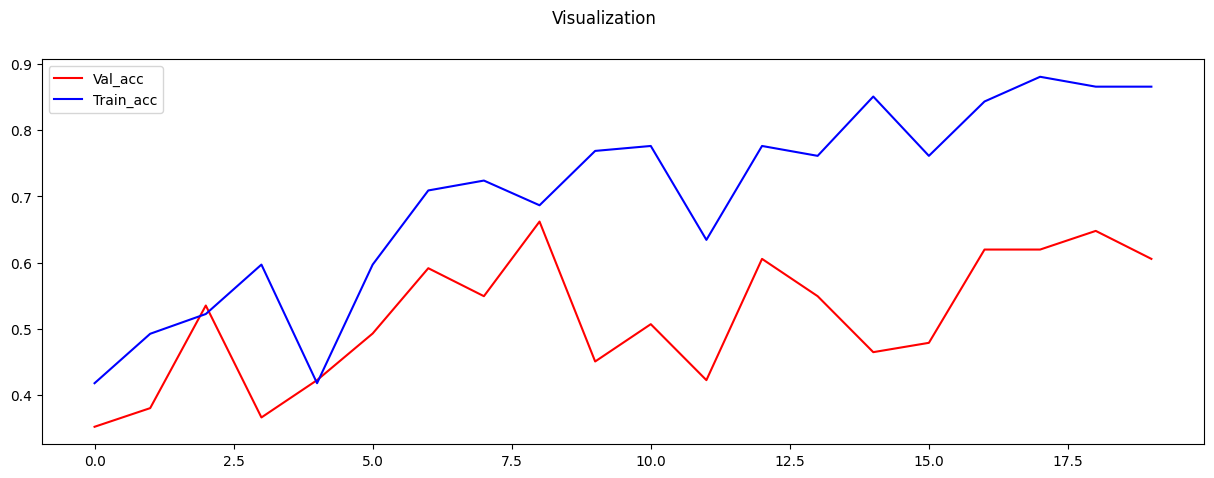

In [124]:
fig, ax = plt.subplots(figsize = (15,5))
ax.plot(test_acc_plot, color = 'red',label = 'Val_acc')
ax.plot(train_acc_plot, color = 'blue',  label = 'Train_acc')
ax.legend()
fig.suptitle("Visualization")
plt.show

# Confustion matrix

In [126]:
set_seed(42)
label_name = ['Corona', 'Floating', 'Void', 'Particle', 'Noise']
model = Encoder(wide_factor_ratio, low_dim_ratio)
model.load_state_dict(torch.load(os.path.join(save_path,'epoch-{}.pth'.format(20)),map_location="cuda:1"))
# model.to('cuda:1')
model.eval()

predict, _ = model(X_test_tensor)
_, prediction = (torch.max(predict, dim =1))
print(prediction)
_,true = torch.max(y_test_tensor, dim =1)
print(true)

tensor([0, 0, 0, 0, 2, 0, 2, 0, 0, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 2,
        2, 4, 4, 4, 2, 4, 2, 4, 2, 4, 2, 2, 4, 2, 4, 2, 2, 2, 2, 2, 2, 4, 4])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4])


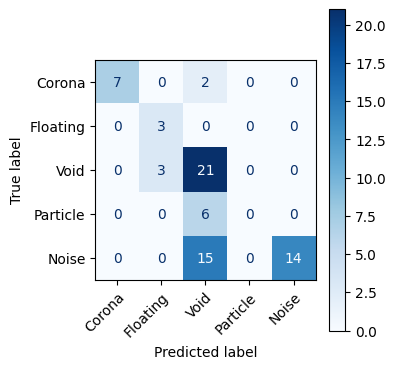

/mnt/c/Users/PC/Documents/Dan/aboutpaperreviews/semi-supervised learning


In [129]:
fig, ax = plt.subplots(figsize=(4, 4))
cm = confusion_matrix(true, prediction)
display = ConfusionMatrixDisplay(cm, display_labels=label_name)
display.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.setp(ax.get_xticklabels(),rotation=45, ha="right", rotation_mode="anchor")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()  # Adjust layout for better spacing

# Save the figure after it has been shown
plt.savefig('Save_model/Confusion_matrix_percent_supervised.png', transparent =True, bbox_inches='tight', dpi=350, format='png')
plt.show()
print(os.getcwd())


In [130]:
# def get_onehot(num_classes, idx):
#     onehot = np.zeros([num_classes], dtype=np.float32)
#     onehot[idx] += 1.0
#     return onehot

# num_classes = 10  # Example: 10 classes
# class_idx = 3     # Example: Index of the class
# onehot_tensor = get_onehot(num_classes, class_idx)
# print(onehot_tensor)

In [131]:
report = classification_report(true.detach().numpy(), prediction.detach().numpy(), target_names = label_name,output_dict=True)
df = pd.DataFrame(report).transpose()
report_df = df.round(4)
print(report_df)


              precision  recall  f1-score  support
Corona           1.0000  0.7778    0.8750   9.0000
Floating         0.5000  1.0000    0.6667   3.0000
Void             0.4773  0.8750    0.6176  24.0000
Particle         0.0000  0.0000    0.0000   6.0000
Noise            1.0000  0.4828    0.6512  29.0000
accuracy         0.6338  0.6338    0.6338   0.6338
macro avg        0.5955  0.6271    0.5621  71.0000
weighted avg     0.7177  0.6338    0.6138  71.0000


/mnt/c/Users/PC/Documents/Dan/aboutpaperreviews/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/c/Users/PC/Documents/Dan/aboutpaperreviews/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/c/Users/PC/Documents/Dan/aboutpaperreviews/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

# Tsne for features extraction

In [132]:
def data_visualization1(X, X_u, y):
    set_seed(42)
    X_tsne = TSNE(n_components=2).fit_transform(X.reshape(X.shape[0],-1))
    X_tsne_ulb = TSNE(n_components=2).fit_transform(X_u.reshape(X_u.shape[0],-1))
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(1,1,1)
    for i in range(len(categories)):
        ax.scatter(X_tsne[y==i,0],X_tsne[y==i,1],edgecolors = color[i], marker = marker_list[i], s = 50, label = categories[i])
    ax.scatter(X_tsne_ulb[:,0], X_tsne_ulb[:,1],edgecolors= 'black', marker='o', s=50, label = 'Unlabel')
    ax.legend(fontsize=8, loc='lower right', bbox_to_anchor=(1, 0))
    ax.tick_params(labelsize=10)

    plt.xlabel("Dimension 1 tSNE")
    plt.ylabel("Dimension 2 tSNE")
    plt.grid(linestyle='--')
    plt.savefig('/home/oem/Tai/master/Save_model/tttt/t-SNE.pdf',dpi =350, bbox_inches = 'tight', transparent = True )
    plt.show()

In [133]:
from sklearn.manifold import TSNE
set_seed(0)
categories = ['Corona', 'Floating', 'Void', 'Particle', 'Noise']
unlabel = ['Unlabeled']
unlabel_marker = ['o']
unlabel_color = ['brown']
marker_list = ['2', '*', 'p', '^', '+']
color = ['red', 'green', 'blue', 'yellow', 'black']

# _, y = torch.max(y_train_tensor, dim=1)
# data_visualization1(X_label_tensor, y)

In [ ]:
# _, y = torch.max(y_train_tensor, dim=1)

# X_u = torch.from_numpy(combined_X_unlab)
# data_visualization1(X_label_tensor,X_u, y)

In [ ]:
# model = Encoder(wide_factor_ratio, low_dim_ratio)
# model.fc2.register_forward_hook(get_activation('fc2'))
# model.load_state_dict(torch.load(os.path.join(save_path,'epoch-{}.pth'.format(highest_epoch_idx))))
# lb_outputs_total = []
# ulb_outputs_total = []
# predict = []
# predict_u = []
# # print(type(model))
# for (x_lb, y_lb), (x_ulb_s, x_ulb_w) in zip(lb_train, unlb_train):
    
#     lb_output, _ = model(x_lb)
#     lb_outputs = activation['fc2']
#     _, label_pre = torch.max(lb_output, dim=1)
#     predict.append(label_pre)
#     lb_outputs_total.append(lb_outputs)

#     ulb_output, _ = model(x_ulb_s)
#     ulb_outputs = activation['fc2']
#     _, label_predict = torch.max(ulb_output, dim=1)
#     predict_u.append(label_predict)
#     ulb_outputs_total.append(ulb_outputs)

# a = np.concatenate(lb_outputs_total)
# b = np.concatenate(predict,axis=0)
# c = np.concatenate(ulb_outputs_total)
# d = np.concatenate(predict_u, axis=0)
# print(a.shape)
# print(b.shape)
# print(c.shape)
# print(d.shape)

In [ ]:
# x_combined = np.concatenate((a, c))
# y_combined = np.concatenate((b,d))
# print(y_combined.shape)
# print(x_combined.shape)

In [135]:
def data_visualization1(X,y, X_u, y_u):
    set_seed(42)
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(1,1,1)
    x_combined = np.concatenate((X, X_u))
    y_combined = np.concatenate((y,y_u))
    
    X_tsne = TSNE(n_components=2).fit_transform(x_combined)
    
    
    for i in range(len(categories)):
        ax.scatter(X_tsne[y_combined==i,0],X_tsne[y_combined==i,1],edgecolors = color[i], marker = marker_list[i], s = 50, label = categories[i])
        # ax.scatter(X_tsne_ulb[y_u==i,0], X_tsne_ulb[y_u==i,1],edgecolors= color[i], marker=marker_list[i], s=50)
        

    ax.legend(fontsize=8, loc='lower right', bbox_to_anchor=(1, 0))
    ax.tick_params(labelsize=10)

    plt.xlabel("Dimension 1 tSNE")
    plt.ylabel("Dimension 2 tSNE")


    plt.grid(linestyle='--')
    plt.savefig('Save_model/Tsne_fc1_1', transparent =True, bbox_inches='tight', dpi=350, format='png')
    plt.show()

In [ ]:
# data_visualization1(a,b,c,d)

In [ ]:
# model = Encoder(wide_factor_ratio, low_dim_ratio)
# model.fc2.register_forward_hook(get_activation('fc2'))
# model.load_state_dict(torch.load(os.path.join(save_path,'epoch-{}.pth'.format(highest_epoch_idx))))
# predict, _ = model(X_test_tensor)
# _, prediction = (torch.max(predict, dim =1))
# print(prediction)
# _,true = torch.max(y_test_tensor, dim =1)
# print(true)
# print(classification_report(true.detach().numpy(), prediction.detach().numpy(), target_names = label_name))

In [136]:
model = Encoder(wide_factor_ratio, low_dim_ratio)
model.fc2.register_forward_hook(get_activation('fc1'))
model.load_state_dict(torch.load(os.path.join(save_path,'epoch-{}.pth'.format(highest_epoch_idx))))
lb_outputs_total = []
ulb_outputs_total = []
predict = []
predict_u = []
# print(type(model))
for (x_lb, y_lb), (x_ulb_s, x_ulb_w) in zip(lb_train, unlb_train):
    
    lb_output, _ = model(x_lb)
    lb_outputs = activation['fc1']
    _, label_pre = torch.max(lb_output, dim=1)
    predict.append(label_pre)
    lb_outputs_total.append(lb_outputs)

    ulb_output, _ = model(x_ulb_s)
    ulb_outputs = activation['fc1']
    _, label_predict = torch.max(ulb_output, dim=1)
    predict_u.append(label_predict)
    ulb_outputs_total.append(ulb_outputs)

a = np.concatenate(lb_outputs_total)
b = np.concatenate(predict,axis=0)
c = np.concatenate(ulb_outputs_total)
d = np.concatenate(predict_u, axis=0)
print(a.shape)
print(b.shape)
print(c.shape)
print(d.shape)

(134, 5)
(134,)
(272, 5)
(272,)


/tmp/ipykernel_1595/817018548.py:12: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('2').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X_tsne[y_combined==i,0],X_tsne[y_combined==i,1],edgecolors = color[i], marker = marker_list[i], s = 50, label = categories[i])
/tmp/ipykernel_1595/817018548.py:12: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X_tsne[y_combined==i,0],X_tsne[y_combined==i,1],edgecolors = color[i], marker = marker_list[i], s = 50, label = categories[i])


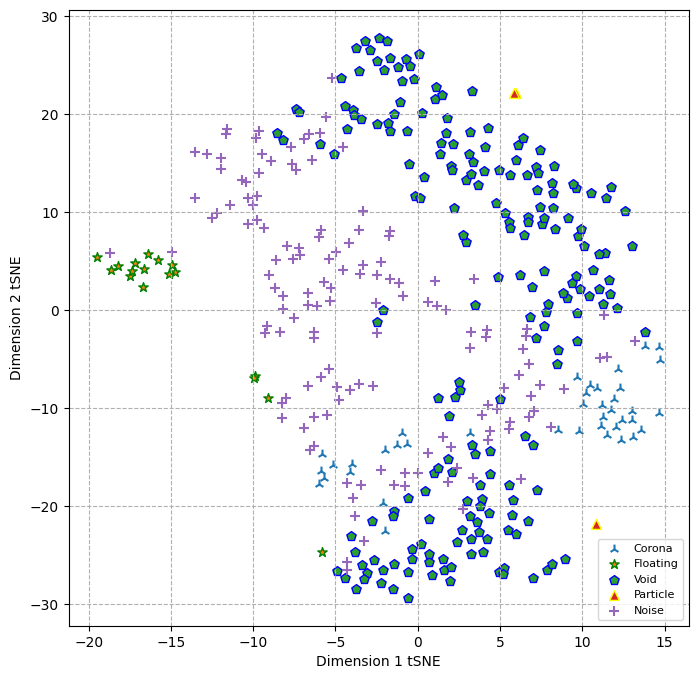

In [137]:
data_visualization1(a,b,c,d)

In [138]:
model = Encoder(wide_factor_ratio, low_dim_ratio)
model.fc4.register_forward_hook(get_activation('fc4'))
model.load_state_dict(torch.load(os.path.join(save_path,'epoch-{}.pth'.format(highest_epoch_idx))))
lb_outputs_total = []
ulb_outputs_total = []
predict = []
predict_u = []
# print(type(model))
for (x_lb, y_lb), (x_ulb_s, x_ulb_w) in zip(lb_train, unlb_train):
    
    _,lb_output = model(x_lb)
    lb_outputs = activation['fc4']
    _, label_pre = torch.max(lb_output, dim=1)
    predict.append(label_pre)
    lb_outputs_total.append(lb_outputs)

    _,ulb_output= model(x_ulb_s)
    ulb_outputs = activation['fc4']
    _, label_predict = torch.max(ulb_output, dim=1)
    predict_u.append(label_predict)
    ulb_outputs_total.append(ulb_outputs)

e = np.concatenate(lb_outputs_total)
g = np.concatenate(predict,axis=0)
h = np.concatenate(ulb_outputs_total)
f = np.concatenate(predict_u, axis=0)
print(e.shape)
print(g.shape)
print(h.shape)
print(f.shape)

(134, 5)
(134,)
(272, 5)
(272,)


In [139]:
def features_visualization1(X,X_u):
    set_seed(42)
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(1,1,1)
    x_combined = np.concatenate((X, X_u))
    
    X_tsne = TSNE(n_components=2).fit_transform(x_combined)
    
    ax.scatter(X_tsne[:,0],X_tsne[:,1],edgecolors = color[i], marker = 'o', s = 50)

        
    # ax.legend(fontsize =8, loc = 'best', bbox_to_anchor = (0,1))
    ax.legend(fontsize=8, loc='lower right', bbox_to_anchor=(1, 0))
    ax.tick_params(labelsize=10)

    plt.xlabel("Dimension 1 tSNE")
    plt.ylabel("Dimension 2 tSNE")
    
    plt.grid(linestyle='--')
    plt.savefig('/home/oem/Tai/master/Save_model/figure/Tsne_fc4_1', transparent =True, bbox_inches='tight', dpi=350, format='png')
    plt.show()

/tmp/ipykernel_190044/407107899.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc='lower right', bbox_to_anchor=(1, 0))


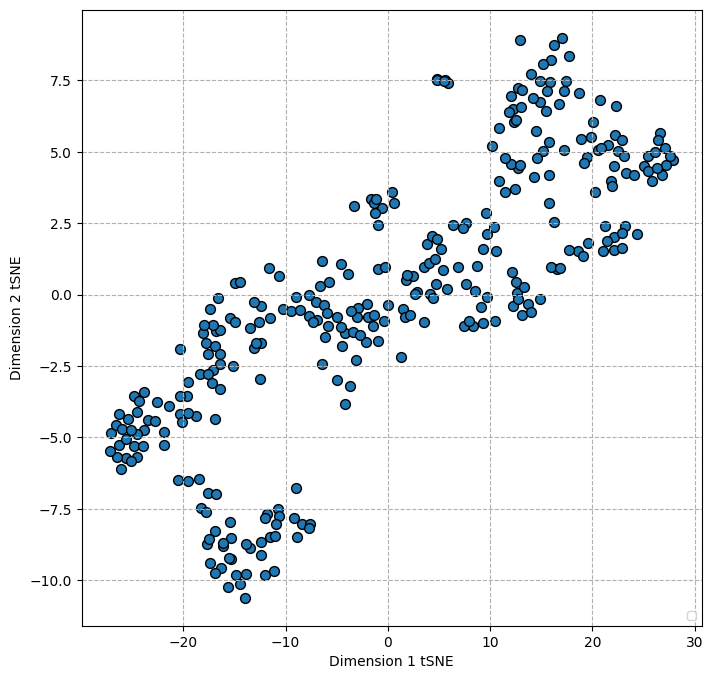

In [ ]:
features_visualization1(e,h)